# 03. 블랙-리터만 Prior 수립

**목표**: 블랙-리터만 모델의 시장 균형 Prior(사전 분포) 산출

| 단계 | 내용 |
|------|------|
| 1 | 데이터 로드 및 수익률 계산 |
| 2 | 공분산 행렬 Σ 계산 (Ledoit-Wolf 수축) |
| 3 | AUM 기반 시장 가중치 w_mkt 계산 |
| 4 | CAPM 역최적화 → 균형 수익률 Π = δΣw_mkt |
| 5 | 결과 저장 (Drive) |

In [1]:
# Colab 환경 설정
import sys
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install -q scikit-learn pandas numpy matplotlib seaborn

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.covariance import LedoitWolf

matplotlib.rcParams['font.family'] = 'NanumGothic' if IN_COLAB else 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 경로 설정 ──────────────────────────────────────────────────────────────────
if IN_COLAB:
    DRIVE_ROOT = '/content/drive/MyDrive/졸업프로젝트/GAPS_대회'
else:
    DRIVE_ROOT = os.path.expanduser('~/school/4-1/졸업프로젝트/GAPS_대회')

DATA_DIR = os.path.join(DRIVE_ROOT, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print('DATA_DIR:', DATA_DIR)

DATA_DIR: /content/drive/MyDrive/졸업프로젝트/GAPS_대회/data


In [3]:
# ── ETF 유니버스 직접 정의 (etf_universe.py 내용 인라인) ──────────────────────
# src/etf_universe.py 를 Colab에서 import하기 어렵기 때문에 인라인으로 처리

ETF_LIST = [
    # FX/원자재 (위험)
    {'ticker': '411060', 'name': 'ACE KRX금현물',             'aum': 52303,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '144600', 'name': 'KODEX 은선물(H)',             'aum': 14590,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '132030', 'name': 'KODEX 골드선물(H)',           'aum':  4821,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '261220', 'name': 'KODEX WTI원유선물(H)',        'aum':  1428,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '261240', 'name': 'KODEX 미국달러선물',          'aum':   724,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '292560', 'name': 'TIGER 일본엔선물',            'aum':   542,  'is_risk': True,  'category': 'fx_commodity'},
    {'ticker': '271060', 'name': 'KODEX 3대농산물선물(H)',      'aum':   252,  'is_risk': True,  'category': 'fx_commodity'},
    # 해외주식_지수 (위험)
    {'ticker': '360750', 'name': 'TIGER 미국S&P500',            'aum': 147821, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '379800', 'name': 'KODEX 미국S&P500',            'aum':  81089, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '133690', 'name': 'TIGER 미국나스닥100',          'aum':  79730, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '379810', 'name': 'KODEX 미국나스닥100',          'aum':  55319, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '381180', 'name': 'TIGER 미국필라델피아반도체나스닥', 'aum': 34100, 'is_risk': True, 'category': 'overseas_index'},
    {'ticker': '360200', 'name': 'ACE 미국S&P500',              'aum':  33475, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '367380', 'name': 'ACE 미국나스닥100',            'aum':  27323, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '379780', 'name': 'RISE 미국S&P500',             'aum':  14147, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '371160', 'name': 'TIGER 차이나항셍테크',          'aum':   9134, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '449180', 'name': 'KODEX 미국S&P500(H)',          'aum':   6946, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '251350', 'name': 'KODEX 선진국MSCI World',       'aum':   4913, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '448290', 'name': 'TIGER 미국S&P500TR(H)',        'aum':   4371, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '241180', 'name': 'TIGER 일본니케이225',           'aum':   4279, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '453810', 'name': 'KODEX 인도Nifty50',            'aum':   4103, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '453870', 'name': 'TIGER 인도니프티50',            'aum':   3951, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '245710', 'name': 'ACE 베트남VN30(합성)',          'aum':   3155, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '448300', 'name': 'TIGER 미국나스닥100TR(H)',       'aum':   2963, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '283580', 'name': 'KODEX 차이나CSI300',            'aum':   2825, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '200250', 'name': 'KIWOOM 인도Nifty50(합성)',      'aum':   2215, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '414780', 'name': 'TIGER 차이나과창판STAR50(합성)', 'aum':   2068, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '372330', 'name': 'KODEX 차이나항셍테크',           'aum':   1627, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '192090', 'name': 'TIGER 차이나CSI300',            'aum':   1575, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '219480', 'name': 'KODEX 미국S&P500선물(H)',        'aum':   1437, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '245340', 'name': 'TIGER 미국다우존스30',           'aum':   1412, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '168580', 'name': 'ACE 중국본토CSI300',            'aum':   1301, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '488500', 'name': 'TIGER 미국S&P500동일가중',       'aum':   1293, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '304940', 'name': 'KODEX 미국나스닥100선물(H)',      'aum':   1056, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '143850', 'name': 'TIGER 미국S&P500선물(H)',        'aum':    982, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '195980', 'name': 'PLUS 신흥국MSCI(합성 H)',        'aum':    920, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '101280', 'name': 'KODEX 일본TOPIX100',             'aum':    624, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '099140', 'name': 'KODEX 차이나H',                  'aum':    437, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '245360', 'name': 'TIGER 차이나HSCEI',              'aum':    400, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '238720', 'name': 'ACE 일본Nikkei225(H)',           'aum':    359, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '195930', 'name': 'TIGER 유로스탁스50(합성 H)',      'aum':    354, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '256440', 'name': 'ACE 인도네시아MSCI(합성)',        'aum':    345, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '280930', 'name': 'KODEX 미국러셀2000(H)',           'aum':    326, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '195970', 'name': 'PLUS 선진국MSCI(합성 H)',        'aum':    244, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '250730', 'name': 'RISE 차이나HSCEI(H)',            'aum':    172, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '291130', 'name': 'ACE 멕시코MSCI(합성)',            'aum':    171, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '195920', 'name': 'TIGER 일본TOPIX(합성 H)',         'aum':    159, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '310080', 'name': 'RISE 중국MSCI China(H)',          'aum':    119, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '105010', 'name': 'TIGER 라틴35',                   'aum':    113, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '379790', 'name': 'RISE 유로스탁스50(H)',            'aum':    109, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '411860', 'name': 'KIWOOM 독일DAX',                 'aum':    104, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '499150', 'name': 'SOL 미국S&P500엔화노출(H)',       'aum':     85, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '189400', 'name': 'PLUS 글로벌MSCI(합성 H)',        'aum':     70, 'is_risk': True,  'category': 'overseas_index'},
    {'ticker': '261920', 'name': 'ACE 필리핀MSCI(합성)',            'aum':     57, 'is_risk': True,  'category': 'overseas_index'},
    # 해외주식_섹터 (위험)
    {'ticker': '381170', 'name': 'TIGER 미국테크TOP10 INDXX',      'aum':  38009, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '458730', 'name': 'TIGER 미국배당다우존스',           'aum':  30379, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '487230', 'name': 'KODEX 미국AI전력핵심인프라',       'aum':  13631, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '371460', 'name': 'TIGER 차이나전기차SOLACTIVE',      'aum':  13027, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '457480', 'name': 'ACE 테슬라밸류체인액티브',         'aum':  11487, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '456600', 'name': 'TIME 글로벌AI인공지능액티브',      'aum':  10744, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '465580', 'name': 'ACE 미국빅테크TOP7 Plus',         'aum':   9716, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '446770', 'name': 'ACE 글로벌반도체TOP4 Plus',       'aum':   9671, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '446720', 'name': 'SOL 미국배당다우존스',             'aum':   9140, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '497570', 'name': 'TIGER 미국필라델피아AI반도체나스닥','aum':   8188, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '402970', 'name': 'ACE 미국배당다우존스',             'aum':   7817, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '390390', 'name': 'KODEX 미국반도체',                'aum':   7809, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '452360', 'name': 'SOL 미국배당다우존스(H)',          'aum':   2026, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '182480', 'name': 'TIGER 미국MSCI리츠(합성 H)',      'aum':   1666, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '429000', 'name': 'TIGER 미국S&P500배당귀족',        'aum':   1556, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '463680', 'name': 'KODEX 미국S&P500테크놀로지',      'aum':    648, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '453640', 'name': 'KODEX 미국S&P500헬스케어',        'aum':    643, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '200030', 'name': 'KODEX 미국S&P500산업재(합성)',    'aum':    500, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '453650', 'name': 'KODEX 미국S&P500금융',            'aum':    435, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '218420', 'name': 'KODEX 미국S&P500에너지(합성)',    'aum':    410, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '352560', 'name': 'KODEX 미국부동산리츠(H)',          'aum':    332, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '493420', 'name': 'SOL 미국배당다우존스TR',           'aum':    325, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '287180', 'name': 'PLUS 미국나스닥테크',              'aum':    316, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '245350', 'name': 'TIGER 유로스탁스배당30',           'aum':    296, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '494410', 'name': 'PLUS 미국S&P500성장주',           'aum':    287, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '460660', 'name': 'RISE 미국S&P배당킹',              'aum':    245, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '185680', 'name': 'KODEX 미국S&P바이오(합성)',        'aum':    200, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '453630', 'name': 'KODEX 미국S&P500필수소비재',      'aum':    176, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '463640', 'name': 'KODEX 미국S&P500유틸리티',        'aum':    162, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '453660', 'name': 'KODEX 미국S&P500경기소비재',      'aum':    139, 'is_risk': True,  'category': 'overseas_sector'},
    {'ticker': '463690', 'name': 'KODEX 미국S&P500커뮤니케이션',    'aum':    131, 'is_risk': True,  'category': 'overseas_sector'},
    # 국내주식_지수 (위험)
    {'ticker': '069500', 'name': 'KODEX 200',          'aum': 164803, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '229200', 'name': 'KODEX 코스닥150',    'aum':  71839, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '102110', 'name': 'TIGER 200',          'aum':  67897, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '278530', 'name': 'KODEX 200TR',        'aum':  52559, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '310970', 'name': 'TIGER MSCI Korea TR','aum':  39380, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '148020', 'name': 'RISE 200',           'aum':  29007, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '232080', 'name': 'TIGER 코스닥150',    'aum':  22098, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '278540', 'name': 'KODEX MSCI Korea TR','aum':  21216, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '294400', 'name': 'KIWOOM 200TR',       'aum':  15375, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '152100', 'name': 'PLUS 200',           'aum':  13051, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '226490', 'name': 'KODEX 코스피',       'aum':   7939, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '361580', 'name': 'RISE 200TR',         'aum':   3842, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '277630', 'name': 'TIGER 코스피',       'aum':   3810, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '295040', 'name': 'SOL 200TR',          'aum':   3540, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '302450', 'name': 'RISE 코스피',        'aum':   3310, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '328370', 'name': 'PLUS 코스피TR',      'aum':   1070, 'is_risk': True,  'category': 'domestic_index'},
    {'ticker': '156080', 'name': 'KODEX MSCI Korea',   'aum':    294, 'is_risk': True,  'category': 'domestic_index'},
    # 국내주식_섹터 (위험)
    {'ticker': '091160', 'name': 'KODEX 반도체',               'aum':  36019, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '161510', 'name': 'PLUS 고배당주',               'aum':  23624, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '102780', 'name': 'KODEX 삼성그룹',              'aum':  23508, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '395160', 'name': 'KODEX AI반도체',              'aum':  20947, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '466920', 'name': 'SOL 조선TOP3플러스',          'aum':  18733, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '305720', 'name': 'KODEX 2차전지산업',           'aum':  18187, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '449450', 'name': 'PLUS K방산',                  'aum':  17803, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '487240', 'name': 'KODEX AI전력핵심설비',        'aum':  15914, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '395270', 'name': 'HANARO Fn K-반도체',          'aum':  14664, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '315930', 'name': 'KODEX Top5PlusTR',            'aum':  13675, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '305540', 'name': 'TIGER 2차전지테마',           'aum':  11376, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '494670', 'name': 'TIGER 조선TOP10',             'aum':   9938, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '445290', 'name': 'KODEX 로봇액티브',            'aum':   9793, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '455850', 'name': 'SOL AI반도체소부장',           'aum':   9687, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '466940', 'name': 'TIGER 은행고배당플러스TOP10', 'aum':   9364, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '463250', 'name': 'TIGER K방산&우주',            'aum':   8830, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139260', 'name': 'TIGER 200 IT',                'aum':   8199, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '462010', 'name': 'TIGER 2차전지소재Fn',         'aum':   7840, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '434730', 'name': 'HANARO 원자력iSelect',        'aum':   7364, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '091180', 'name': 'KODEX 자동차',                'aum':   5224, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '091170', 'name': 'KODEX 은행',                  'aum':   4569, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139230', 'name': 'TIGER 200 중공업',            'aum':   3928, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '325010', 'name': 'KODEX 성장주',                'aum':   1495, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '363580', 'name': 'KODEX 200IT TR',              'aum':   1021, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139220', 'name': 'TIGER 200 건설',              'aum':    491, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139270', 'name': 'TIGER 200 금융',              'aum':    430, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '227540', 'name': 'TIGER 200 헬스케어',          'aum':    316, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '147970', 'name': 'TIGER 모멘텀',                'aum':    294, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139250', 'name': 'TIGER 200 에너지화학',        'aum':    288, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '174350', 'name': 'TIGER 로우볼',                'aum':     94, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '227550', 'name': 'TIGER 200 산업재',            'aum':     91, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '227570', 'name': 'TIGER 우량가치',              'aum':     88, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139290', 'name': 'TIGER 200 경기소비재',        'aum':     83, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '139240', 'name': 'TIGER 200 철강소재',          'aum':     72, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '315270', 'name': 'TIGER 200커뮤니케이션서비스', 'aum':     66, 'is_risk': True,  'category': 'domestic_sector'},
    {'ticker': '227560', 'name': 'TIGER 200 생활소비재',        'aum':     42, 'is_risk': True,  'category': 'domestic_sector'},
    # 금리연계형/초단기채권 (안전)
    {'ticker': '459580', 'name': 'KODEX CD금리액티브(합성)',     'aum':  79731, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '488770', 'name': 'KODEX 머니마켓액티브',         'aum':  72891, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '423160', 'name': 'KODEX KOFR금리액티브(합성)',   'aum':  43045, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '455890', 'name': 'RISE 머니마켓액티브',          'aum':  22406, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '469830', 'name': 'SOL 초단기채권액티브',         'aum':   9092, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '153130', 'name': 'KODEX 단기채권',               'aum':   7321, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '456610', 'name': 'TIGER 미국달러SOFR금리액티브(합성)', 'aum': 6550, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '196230', 'name': 'RISE 단기통안채',              'aum':   2081, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '455960', 'name': 'RISE 미국달러SOFR금리액티브(합성)', 'aum':  602, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '468370', 'name': 'KODEX iShares미국인플레이션국채액티브', 'aum': 187, 'is_risk': False, 'category': 'mmf_ultrashort'},
    {'ticker': '430500', 'name': 'KIWOOM 물가채KIS',             'aum':    113, 'is_risk': False, 'category': 'mmf_ultrashort'},
    # 해외채권_회사채 (안전)
    {'ticker': '458260', 'name': 'TIGER 미국투자등급회사채액티브(H)', 'aum':  2883, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '468380', 'name': 'KODEX iShares미국하이일드액티브', 'aum':  1160, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '455660', 'name': 'ACE 미국하이일드액티브(H)',      'aum':   528, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '468630', 'name': 'KODEX iShares미국투자등급회사채액티브', 'aum': 367, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '332620', 'name': 'PLUS 미국장기우량회사채',       'aum':   208, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '332610', 'name': 'PLUS 미국단기회사채(AAA~A)',    'aum':   131, 'is_risk': False, 'category': 'overseas_bond_corp'},
    {'ticker': '182490', 'name': 'TIGER 단기선진하이일드(합성 H)', 'aum':   82, 'is_risk': False, 'category': 'overseas_bond_corp'},
    # 해외채권_종합 (안전)
    {'ticker': '453850', 'name': 'ACE 미국30년국채액티브(H)',              'aum': 18200, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '458250', 'name': 'TIGER 미국30년국채스트립액티브(합성 H)', 'aum':  6231, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '484790', 'name': 'KODEX 미국30년국채액티브(H)',             'aum':  5934, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '329750', 'name': 'TIGER 미국달러단기채권액티브',            'aum':  4708, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '472870', 'name': 'RISE 미국30년국채엔화노출(합성 H)',        'aum':  3570, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '476760', 'name': 'ACE 미국30년국채액티브',                  'aum':  3171, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '305080', 'name': 'TIGER 미국채10년선물',                   'aum':  2446, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '308620', 'name': 'KODEX 미국10년국채선물',                  'aum':  1138, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '476750', 'name': 'ACE 미국30년국채엔화노출액티브(H)',        'aum':   860, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '489000', 'name': 'PLUS 일본엔화초단기국채(합성)',            'aum':   219, 'is_risk': False, 'category': 'overseas_bond'},
    {'ticker': '267440', 'name': 'RISE 미국장기국채선물(H)',                 'aum':    51, 'is_risk': False, 'category': 'overseas_bond'},
    # 국내채권_회사채 (안전)  ※ 특수 티커 2개 제외
    {'ticker': '273130', 'name': 'KODEX 종합채권(AA-이상)액티브',  'aum': 38484, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '385540', 'name': 'RISE 종합채권(A-이상)액티브',   'aum': 17737, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '451540', 'name': 'TIGER 종합채권(AA-이상)액티브', 'aum': 10134, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '438330', 'name': 'TIGER 투자등급회사채액티브',    'aum':  6984, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '363570', 'name': 'KODEX 장기종합채권(AA-이상)액티브', 'aum': 3200, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '278620', 'name': 'PLUS 단기채권액티브',           'aum':   532, 'is_risk': False, 'category': 'domestic_bond_corp'},
    {'ticker': '336160', 'name': 'RISE 금융채액티브',             'aum':   417, 'is_risk': False, 'category': 'domestic_bond_corp'},
    # 국내채권_종합 (안전)
    {'ticker': '157450', 'name': 'TIGER 단기통안채',          'aum':  9750, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '114260', 'name': 'KODEX 국고채3년',           'aum':  5353, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '148070', 'name': 'KIWOOM 국고채10년',         'aum':  4925, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '439870', 'name': 'KODEX 국고채30년액티브',    'aum':  3549, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '302190', 'name': 'TIGER 중장기국채',          'aum':  2950, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '272560', 'name': 'RISE 단기국공채액티브',     'aum':  1915, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '114100', 'name': 'RISE 국고채3년',            'aum':  1798, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '451530', 'name': 'TIGER 국고채30년스트립액티브', 'aum': 1444, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '298340', 'name': 'PLUS 국채선물3년',          'aum':   600, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '426150', 'name': 'WON 대한민국국고채액티브',  'aum':   530, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '152380', 'name': 'KODEX 국채선물10년',        'aum':   402, 'is_risk': False, 'category': 'domestic_bond'},
    {'ticker': '397420', 'name': 'RISE 국채선물5년추종',      'aum':    52, 'is_risk': False, 'category': 'domestic_bond'},
]

etf_df = pd.DataFrame(ETF_LIST)
print(f'ETF 유니버스: {len(etf_df)}개 (특수 티커 0061Z0, 0016X0 제외)')

ETF 유니버스: 186개 (특수 티커 0061Z0, 0016X0 제외)


## Step 1 — 가격 데이터 로드 및 수익률 계산

In [4]:
price_path = os.path.join(DATA_DIR, 'etf_close_wide.parquet')
price_df = pd.read_parquet(price_path)
price_df.index = pd.to_datetime(price_df.index)
price_df = price_df.sort_index()

print(f'원본 shape: {price_df.shape}')
print(f'기간: {price_df.index[0].date()} ~ {price_df.index[-1].date()}')
print(f'전체 NaN 비율: {price_df.isna().mean().mean():.1%}')

원본 shape: (1815, 188)
기간: 2019-01-02 ~ 2026-05-26
전체 NaN 비율: 25.5%


In [5]:
# ── 데이터 품질 확인 ──────────────────────────────────────────────────────────
nan_pct = price_df.isna().mean().sort_values(ascending=False)
print('NaN 비율 상위 20 ETF:')
print(nan_pct.head(20).to_string())

# 전체 기간의 50% 이상 결측이면 제외
valid_tickers = nan_pct[nan_pct < 0.5].index.tolist()
dropped = [t for t in price_df.columns if t not in valid_tickers]
print(f'\n제외 ETF ({len(dropped)}개, 결측 ≥50%): {dropped}')
price_df = price_df[valid_tickers]

NaN 비율 상위 20 ETF:
0061Z0    0.876033
0016X0    0.829752
499150    0.803306
497570    0.800551
494410    0.786777
494670    0.786777
493420    0.781818
489000    0.763085
488770    0.760331
488500    0.754821
487230    0.749311
487240    0.749311
484790    0.741047
476750    0.705234
476760    0.705234
472870    0.678237
469830    0.658953
468380    0.651791
468370    0.651791
468630    0.651791

제외 ETF (57개, 결측 ≥50%): ['449180', '448290', '453810', '453870', '448300', '488500', '499150', '458730', '487230', '457480', '456600', '465580', '446770', '446720', '497570', '452360', '463680', '453640', '453650', '493420', '494410', '460660', '453630', '463640', '453660', '463690', '466920', '449450', '487240', '494670', '445290', '455850', '466940', '463250', '462010', '459580', '488770', '455890', '469830', '456610', '455960', '468370', '458260', '468380', '455660', '468630', '453850', '458250', '484790', '472870', '476760', '476750', '489000', '451540', '451530', '0061Z0', '0016X0']


In [6]:
# ── 공분산 계산 기간 설정 ──────────────────────────────────────────────────────
# 백테스트 워밍업과 동일하게 2021-01-01 이후 데이터 사용
CRIT_DATE = '2021-01-01'
price_sub = price_df.loc[CRIT_DATE:].copy()

# forward-fill → 거래 없는 날(ETF 특성상 드물지만) 처리
price_sub = price_sub.ffill()

# 일간 로그 수익률
log_ret = np.log(price_sub / price_sub.shift(1)).dropna(how='all')

# 컬럼별 결측 처리: 상장일 이전은 0으로 채우지 않고 제거 후 재확인
# 충분한 데이터(≥252일, 약 1년)가 있는 ETF만 최종 사용
obs_count = log_ret.count()
sufficient = obs_count[obs_count >= 252].index.tolist()
insufficient = [t for t in log_ret.columns if t not in sufficient]
print(f'관측 불충분 제외: {len(insufficient)}개 → {insufficient[:10]}{'...' if len(insufficient)>10 else ''}')

log_ret = log_ret[sufficient]
print(f'최종 수익률 행렬: {log_ret.shape}  (거래일 × ETF 수)')

관측 불충분 제외: 0개 → []
최종 수익률 행렬: (1320, 131)  (거래일 × ETF 수)


## Step 2 — 공분산 행렬 Σ (Ledoit-Wolf 수축 추정)

In [7]:
# NaN을 0으로 대체 후 Ledoit-Wolf 적용 (상장일 전 수익률이 없는 경우)
ret_filled = log_ret.fillna(0.0).values  # shape: (T, N)

lw = LedoitWolf()
lw.fit(ret_filled)

# 연율화 (거래일 기준 252일)
Sigma = lw.covariance_ * 252
tickers_final = log_ret.columns.tolist()
N = len(tickers_final)

Sigma_df = pd.DataFrame(Sigma, index=tickers_final, columns=tickers_final)

print(f'Σ shape: {Sigma_df.shape}')
print(f'Ledoit-Wolf shrinkage coeff: {lw.shrinkage_:.4f}')
print(f'연율화 변동성 (상위 5): ')
vols = np.sqrt(np.diag(Sigma))
vol_s = pd.Series(vols, index=tickers_final).sort_values(ascending=False)
print(vol_s.head(5).to_string())

Σ shape: (131, 131)
Ledoit-Wolf shrinkage coeff: 0.0153
연율화 변동성 (상위 5): 
261220    0.404447
305540    0.395386
305720    0.390360
144600    0.376213
091160    0.354520


/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51116 (\N{HANGUL SYLLABLE JAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 54644 (\N{HANGUL SYLLABLE HAE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50808 (\N{HANGUL SYLLABLE OE}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/l

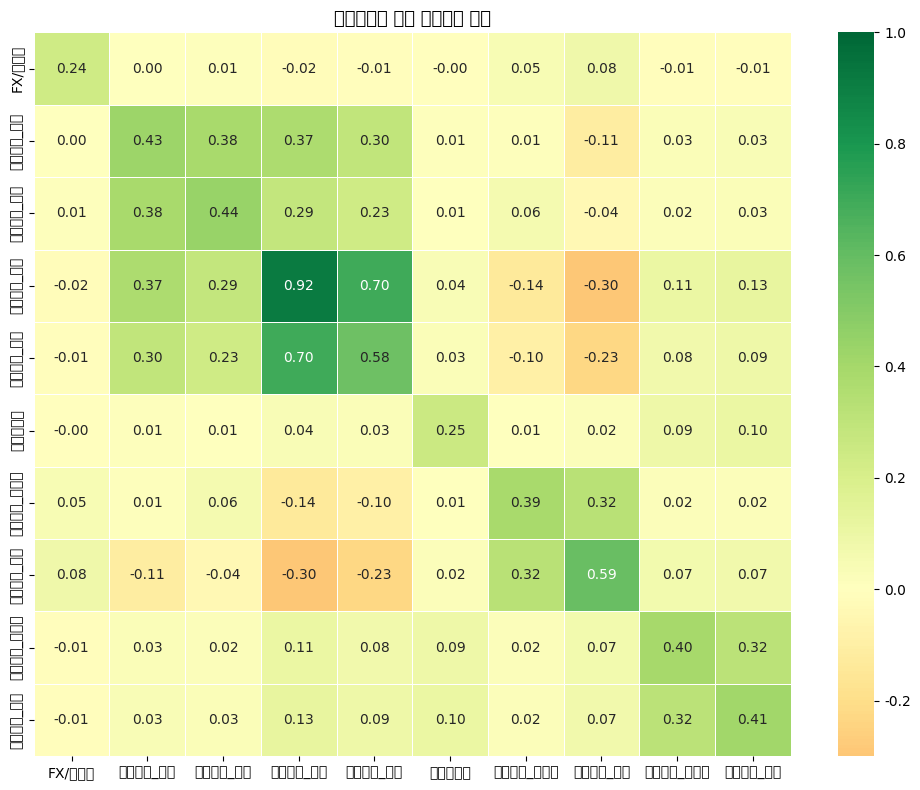

In [8]:
# ── 상관관계 히트맵 (카테고리별 평균) ────────────────────────────────────────
# 전체 188×188 히트맵은 너무 크므로 카테고리별 평균 상관계수 행렬 시각화

# 티커→카테고리 매핑
ticker_cat = etf_df.set_index('ticker')['category']

CATEGORY_LABELS = {
    'fx_commodity':       'FX/원자재',
    'overseas_index':     '해외주식_지수',
    'overseas_sector':    '해외주식_섹터',
    'domestic_index':     '국내주식_지수',
    'domestic_sector':    '국내주식_섹터',
    'mmf_ultrashort':     '초단기채권',
    'overseas_bond_corp': '해외채권_회사채',
    'overseas_bond':      '해외채권_종합',
    'domestic_bond_corp': '국내채권_회사채',
    'domestic_bond':      '국내채권_종합',
}

# 상관계수 행렬
corr_df = Sigma_df.copy()
for t in corr_df.columns:
    corr_df[t] = corr_df[t] / (np.sqrt(Sigma_df.loc[t, t]) * np.sqrt(np.diag(Sigma_df.values)))

# 카테고리별 평균 상관관계
cats = [CATEGORY_LABELS.get(ticker_cat.get(t, 'unknown'), 'unknown') for t in tickers_final]
cat_s = pd.Series(cats, index=tickers_final)
unique_cats = [v for v in CATEGORY_LABELS.values() if v in cat_s.values]

cat_corr = pd.DataFrame(index=unique_cats, columns=unique_cats, dtype=float)
for ci in unique_cats:
    for cj in unique_cats:
        ti = cat_s[cat_s == ci].index
        tj = cat_s[cat_s == cj].index
        if len(ti) > 0 and len(tj) > 0:
            cat_corr.loc[ci, cj] = corr_df.loc[ti, tj].values.mean()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cat_corr.astype(float), annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-0.3, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('카테고리별 평균 상관관계 행렬', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'bl_category_corr.png'), dpi=150)
plt.show()

## Step 3 — 시장 가중치 w_mkt (AUM 비례)

In [10]:
# ── AUM 가중치 계산 ───────────────────────────────────────────────────────────
# 데이터가 없어서 제외된 티커는 w=0 처리
aum_map = etf_df.set_index('ticker')['aum']

aum_vals = pd.Series(
    {t: aum_map.get(t, 0.0) for t in tickers_final},
    dtype=float
)
w_mkt = aum_vals / aum_vals.sum()
w_mkt.name = 'w_mkt'

print('w_mkt 합계:', w_mkt.sum().round(6))
print('\n상위 10 ETF (시장 가중치):')
print(w_mkt.sort_values(ascending=False).head(10).apply(lambda x: f'{x:.4%}').to_string())

# 카테고리별 집계 (확인용)
cat_w = pd.Series(
    {CATEGORY_LABELS.get(ticker_cat.get(t, '?'), '?'): w_mkt[t] for t in tickers_final}
).groupby(level=0).sum().sort_values(ascending=False)
print('\n카테고리별 시장 가중치 합:')
print(cat_w.apply(lambda x: f'{x:.2%}').to_string())

w_mkt 합계: 1.0

상위 10 ETF (시장 가중치):
069500    10.6991%
360750     9.5966%
379800     5.2643%
133690     5.1761%
229200     4.6638%
102110     4.4079%
379810     3.5913%
278530     3.4121%
411060     3.3955%
423160     2.7945%

카테고리별 시장 가중치 합:
국내주식_지수     1.43%
초단기채권       0.48%
해외채권_종합     0.16%
FX/원자재      0.04%
국내채권_회사채    0.03%
국내주식_섹터     0.03%
국내채권_종합     0.03%
해외주식_섹터     0.01%
해외주식_지수     0.01%
해외채권_회사채    0.01%


## Step 4 — 균형 수익률 Π = δΣw_mkt

In [11]:
# ── 위험 회피 계수 δ 추정 ──────────────────────────────────────────────────────
# δ = (E[r_m] - r_f) / σ_m^2  ← CAPM에서 역산
# 시장 포트폴리오 수익률/변동성으로 추정

w_arr = w_mkt.values  # (N,)
market_ret_daily = (log_ret.fillna(0) * w_mkt).sum(axis=1)  # 일별 시장 포트 수익률

E_rm = market_ret_daily.mean() * 252          # 연율화 기대수익률
var_m = market_ret_daily.var() * 252          # 연율화 분산

# 무위험수익률: 한국 3년 국고채 근사 (현재 ~3.5%)
r_f = 0.035
delta = (E_rm - r_f) / var_m

print(f'시장 포트폴리오 연율화 기대수익률: {E_rm:.2%}')
print(f'시장 포트폴리오 연율화 분산:       {var_m:.4f}')
print(f'무위험수익률 r_f:                  {r_f:.2%}')
print(f'추정 δ:                            {delta:.4f}')

# δ가 비합리적(음수 또는 >10)이면 표준값 2.5 사용
if not (0.5 <= delta <= 10.0):
    print(f'\n⚠️  δ={delta:.2f} 이상값 → 표준값 2.5 사용')
    delta = 2.5

시장 포트폴리오 연율화 기대수익률: 18.86%
시장 포트폴리오 연율화 분산:       0.0245
무위험수익률 r_f:                  3.50%
추정 δ:                            6.2627


In [12]:
# ── Π = δ × Σ × w_mkt (역최적화) ────────────────────────────────────────────
Pi = delta * Sigma @ w_arr  # shape: (N,)
Pi_s = pd.Series(Pi, index=tickers_final, name='Pi_annual')

print(f'균형 수익률 Π 기초 통계:')
print(f'  평균: {Pi_s.mean():.4%}')
print(f'  최솟값: {Pi_s.min():.4%}  최댓값: {Pi_s.max():.4%}')

print('\n상위 10 ETF (균형 수익률 높은 순):')
top_pi = Pi_s.sort_values(ascending=False).head(10)
for t, v in top_pi.items():
    name = etf_df.set_index('ticker').loc[t, 'name'] if t in etf_df['ticker'].values else '?'
    print(f'  {t} {name:<30s}  {v:.4%}')

print('\n하위 10 ETF (균형 수익률 낮은 순):')
bot_pi = Pi_s.sort_values(ascending=True).head(10)
for t, v in bot_pi.items():
    name = etf_df.set_index('ticker').loc[t, 'name'] if t in etf_df['ticker'].values else '?'
    print(f'  {t} {name:<30s}  {v:.4%}')

균형 수익률 Π 기초 통계:
  평균: 10.8673%
  최솟값: -3.5689%  최댓값: 28.5507%

상위 10 ETF (균형 수익률 높은 순):
  091160 KODEX 반도체                       28.5507%
  395160 KODEX AI반도체                     27.0395%
  139260 TIGER 200 IT                    26.5003%
  363580 KODEX 200IT TR                  26.3614%
  395270 HANARO Fn K-반도체                 25.9505%
  381180 TIGER 미국필라델피아반도체나스닥             24.1334%
  229200 KODEX 코스닥150                    23.2396%
  305540 TIGER 2차전지테마                    23.0855%
  232080 TIGER 코스닥150                    22.9948%
  325010 KODEX 성장주                       22.9721%

하위 10 ETF (균형 수익률 낮은 순):
  261240 KODEX 미국달러선물                    -3.5689%
  329750 TIGER 미국달러단기채권액티브               -3.5650%
  332610 PLUS 미국단기회사채(AAA~A)             -3.3752%
  292560 TIGER 일본엔선물                     -3.2535%
  308620 KODEX 미국10년국채선물                 -3.1751%
  305080 TIGER 미국채10년선물                  -3.1056%
  332620 PLUS 미국장기우량회사채                  -1.0406%
  153130 KODEX 단기채권                 

/tmp/ipykernel_3019/151441284.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(cat_order, rotation=30, ha='right')
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 44397 (\N{HANGUL SYLLABLE GUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 45236 (\N{HANGUL SYLLABLE NAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 49885 (\N{HANGUL SYLLABLE SIG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3019/151441284.py:17: UserWarning: Glyph 49688 (\N

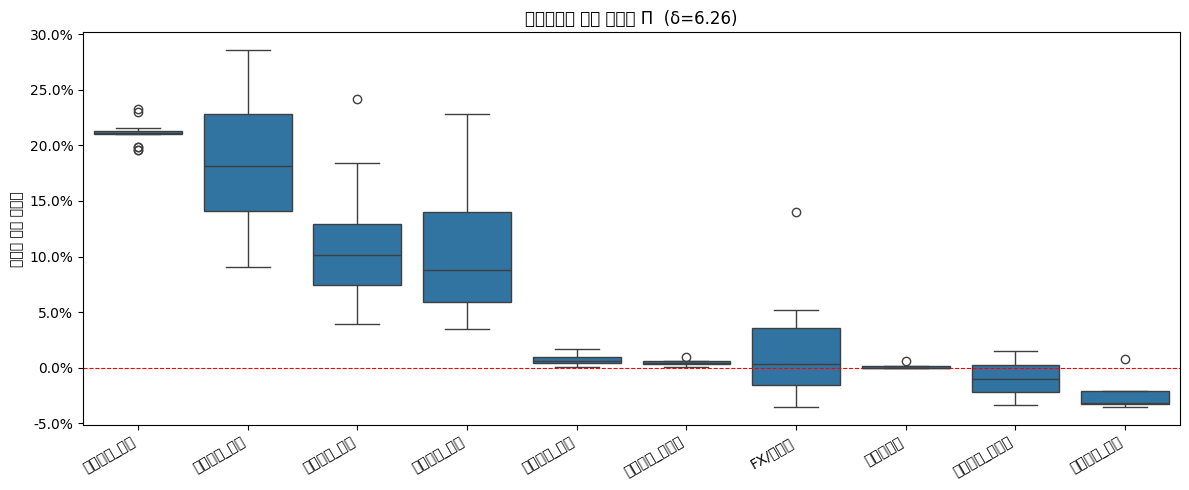

In [16]:
# ── 카테고리별 균형 수익률 분포 시각화 ─────────────────────────────────────────
Pi_df = Pi_s.reset_index()
Pi_df.columns = ['ticker', 'Pi']
Pi_df['category'] = Pi_df['ticker'].map(ticker_cat)
Pi_df['cat_label'] = Pi_df['category'].map(CATEGORY_LABELS).fillna('기타')

cat_order = Pi_df.groupby('cat_label')['Pi'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=Pi_df, x='cat_label', y='Pi', order=cat_order, ax=ax)
ax.set_xticklabels(cat_order, rotation=30, ha='right')
ax.set_title(f'카테고리별 균형 수익률 Π  (δ={delta:.2f})')
ax.set_xlabel('')
ax.set_ylabel('연율화 균형 수익률')
ax.yaxis.set_major_formatter(matplotlib.ticker.PercentFormatter(xmax=1))
ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, 'bl_pi_by_category.png'), dpi=150)
plt.show()

## Step 5 — 결과 저장

In [17]:
import json

# ① 공분산 행렬 Σ (parquet)
Sigma_df.to_parquet(os.path.join(DATA_DIR, 'bl_sigma.parquet'))

# ② 시장 가중치 w_mkt (CSV)
w_mkt.to_csv(os.path.join(DATA_DIR, 'bl_w_mkt.csv'), header=True)

# ③ 균형 수익률 Π (CSV)
Pi_s.to_csv(os.path.join(DATA_DIR, 'bl_pi.csv'), header=True)

# ④ 메타 정보 (delta, r_f, 기간, N)
meta = {
    'delta': float(delta),
    'r_f': float(r_f),
    'n_assets': int(N),
    'tickers': tickers_final,
    'data_start': str(price_sub.index[0].date()),
    'data_end': str(price_sub.index[-1].date()),
    'cov_method': 'LedoitWolf',
    'annualization': 252,
}
with open(os.path.join(DATA_DIR, 'bl_meta.json'), 'w', encoding='utf-8') as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print('저장 완료:')
print(f'  bl_sigma.parquet  — Σ ({N}×{N})')
print(f'  bl_w_mkt.csv      — w_mkt ({N}개)')
print(f'  bl_pi.csv         — Π ({N}개)')
print(f'  bl_meta.json      — δ={delta:.2f}, r_f={r_f:.2%}')
print(f'  bl_category_corr.png')
print(f'  bl_pi_by_category.png')

저장 완료:
  bl_sigma.parquet  — Σ (131×131)
  bl_w_mkt.csv      — w_mkt (131개)
  bl_pi.csv         — Π (131개)
  bl_meta.json      — δ=6.26, r_f=3.50%
  bl_category_corr.png
  bl_pi_by_category.png


## 결과 요약

| 산출물 | 설명 | 다음 단계 활용 |
|--------|------|---------------|
| `bl_sigma.parquet` | ETF 레벨 공분산 행렬 Σ (Ledoit-Wolf) | MVO 최적화 |
| `bl_w_mkt.csv` | AUM 기반 시장 가중치 | 카테고리→ETF 매핑 |
| `bl_pi.csv` | ETF 레벨 균형 수익률 Π = δΣw_mkt | BL Prior |
| `bl_meta.json` | δ, r_f, 기간 등 메타 | 재현성 확보 |

**다음 노트북**: `04_rl_portfolio_agent.ipynb`
- 카테고리별 월별 수익률 계산 + Σ_cat (10×10) 추정
- PPO 강화학습 에이전트 학습 → `w_RL` (카테고리 배분 비중) 시계열 추출
- 저장: `bl_sigma_cat.npy`, `bl_pi_cat.npy`, `rl_w_RL.parquet`

**그 다음**: `05_bl_fusion_mvo.ipynb`
- `w_RL`, `w_Human` 역최적화 → `Q_RL = δΣw_RL`, `Q_Human = δΣw_Human`
- BL 융합 → 사후 기대수익률 `E[R]`
- MVO (하드 제약: 위험 ≤70%, 회전율 ≥10%) → 최종 ETF 비중 `w*`